In [3]:
from pycaret.datasets import get_data 
import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_column', 2500)
pd.set_option('display.max_colwidth', 2500)

In [4]:
dataset = get_data("bike")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1/1/2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2,1/1/2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,3,1/1/2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,4,1/1/2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,5,1/1/2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [5]:
print(dataset.info)

<bound method DataFrame.info of        instant      dteday  season  yr  mnth  hr  holiday  weekday  \
0            1    1/1/2011       1   0     1   0        0        6   
1            2    1/1/2011       1   0     1   1        0        6   
2            3    1/1/2011       1   0     1   2        0        6   
3            4    1/1/2011       1   0     1   3        0        6   
4            5    1/1/2011       1   0     1   4        0        6   
...        ...         ...     ...  ..   ...  ..      ...      ...   
17374    17375  12/31/2012       1   1    12  19        0        1   
17375    17376  12/31/2012       1   1    12  20        0        1   
17376    17377  12/31/2012       1   1    12  21        0        1   
17377    17378  12/31/2012       1   1    12  22        0        1   
17378    17379  12/31/2012       1   1    12  23        0        1   

       workingday  weathersit  temp   atemp   hum  windspeed  cnt  
0               0           1  0.24  0.2879  0.81     0.000

In [6]:
dataset.season.unique()

array([1, 2, 3, 4], dtype=int64)

In [7]:
dataset.cnt.value_counts()

5      260
6      236
4      231
3      224
2      208
      ... 
913      1
847      1
777      1
661      1
636      1
Name: cnt, Length: 869, dtype: int64

In [8]:
dataset.shape

(17379, 15)

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  cnt         17379 non-null  int64  
dtypes: float64(4), int64(10), object(1)
memory usage: 2.0+ MB


In [10]:
# sample 5% of data to be used as unseen data
data = dataset.sample(frac=0.95, random_state=786)
data_unseen = dataset.drop(data.index)
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
# print the revised shape
print('Data for Modeling: ' + str(data.shape))
print('Unseen Data For Predictions: ' + str(data_unseen.shape))

Data for Modeling: (16510, 15)
Unseen Data For Predictions: (869, 15)


In [11]:
from pycaret import classification
s = classification.setup(data = data,
                         train_size = 0.9,
                         target = 'season', 
                         session_id=123)

,Description,Value
0,Session id,123
1,Target,season
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2, 4: 3"
4,Original data shape,"(16510, 15)"
5,Transformed data shape,"(16510, 15)"
6,Transformed train set shape,"(14859, 15)"
7,Transformed test set shape,"(1651, 15)"
8,Numeric features,13
9,Categorical features,1


In [12]:
# check transformed X_train
classification.get_config('X_train')

,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,3019,5/10/2011,0,5,16,0,2,1,1,0.66,0.6212,0.31,0.1045,327
1,10894,4/4/2012,1,4,1,0,3,1,1,0.46,0.4545,0.59,0.0000,11
2,13236,7/10/2012,1,7,16,0,2,1,1,0.80,0.7273,0.43,0.2239,435
3,8553,12/28/2011,0,12,2,0,3,1,1,0.32,0.3030,0.61,0.2537,7
4,17244,12/26/2012,1,12,8,0,3,1,3,0.20,0.1818,0.86,0.3284,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14854,17112,12/20/2012,1,12,18,0,4,1,2,0.34,0.3333,0.71,0.1940,381
14855,3325,5/23/2011,0,5,10,0,1,1,1,0.66,0.6212,0.74,0.2985,121
14856,6668,10/10/2011,0,10,9,1,1,0,1,0.54,0.5152,0.77,0.0000,219
14857,13849,8/5/2012,1,8,5,0,0,0,1,0.72,0.6970,0.74,0.2537,19


In [13]:
# list columns of transformed X_train 
classification.get_config('X_train').columns

Index(['instant', 'dteday', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [14]:
# check available models
classification.models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsClassifier,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDClassifier,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessClassifier,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron.MLPClassifier,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [15]:
# train all models using default hyperparameters
best = classification.compare_models(exclude=['nb'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.9999,1.0000,0.9999,0.9999,0.9999,0.9999,0.9999,0.0350
rf,Random Forest Classifier,0.9999,1.0000,0.9999,0.9999,0.9999,0.9999,0.9999,0.0600
gbc,Gradient Boosting Classifier,0.9999,1.0000,0.9999,0.9999,0.9999,0.9999,0.9999,0.0770
et,Extra Trees Classifier,0.9999,1.0000,0.9999,0.9999,0.9999,0.9999,0.9999,0.0620
lightgbm,Light Gradient Boosting Machine,0.9999,1.0000,0.9999,0.9999,0.9999,0.9999,0.9999,0.1540
knn,K Neighbors Classifier,0.9966,0.9999,0.9966,0.9967,0.9966,0.9955,0.9955,0.2070
lda,Linear Discriminant Analysis,0.9812,0.9942,0.9812,0.9814,0.9806,0.9749,0.9754,0.0380
ridge,Ridge Classifier,0.8175,0.0000,0.8175,0.8443,0.7958,0.7568,0.7735,0.0320
qda,Quadratic Discriminant Analysis,0.8119,0.8973,0.8119,0.9105,0.8118,0.7502,0.7850,0.0350
ada,Ada Boost Classifier,0.7816,0.9258,0.7816,0.6697,0.7076,0.7075,0.7622,0.0470


Processing:   0%|          | 0/57 [00:00<?, ?it/s]

In [16]:
type(best)

sklearn.tree._classes.DecisionTreeClassifier

In [17]:
# train individual model
dt = classification.create_model('dt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [18]:
print(dt)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       random_state=123, splitter='best')


In [19]:
knn = classification.create_model('knn')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9987,1.0000,0.9987,0.9987,0.9987,0.9982,0.9982
1,0.9980,1.0000,0.9980,0.9980,0.9980,0.9973,0.9973
2,0.9953,1.0000,0.9953,0.9953,0.9953,0.9937,0.9937
3,0.9966,1.0000,0.9966,0.9966,0.9966,0.9955,0.9955
4,0.9939,1.0000,0.9939,0.9940,0.9939,0.9919,0.9919
5,0.9966,0.9995,0.9966,0.9967,0.9966,0.9955,0.9955
6,0.9993,1.0000,0.9993,0.9993,0.9993,0.9991,0.9991
7,0.9980,0.9996,0.9980,0.9980,0.9980,0.9973,0.9973
8,0.9946,0.9995,0.9946,0.9947,0.9946,0.9928,0.9928


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [20]:
rf = classification.create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [21]:
# tune hyperparameters of model
tuned_dt = classification.tune_model(dt, 
#                       search_library = 'optuna'
                     )

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [22]:
print(tuned_dt)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       random_state=123, splitter='best')


In [23]:
print(tuned_dt)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       random_state=123, splitter='best')


In [24]:
import numpy as np
tuned_knn = classification.tune_model(knn, custom_grid = {'n_neighbors' : np.arange(0,50,1)})

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9960,1.0000,0.9960,0.9960,0.9960,0.9946,0.9946
1,0.9980,1.0000,0.9980,0.9980,0.9980,0.9973,0.9973
2,0.9946,0.9977,0.9946,0.9946,0.9946,0.9928,0.9928
3,0.9960,1.0000,0.9960,0.9960,0.9960,0.9946,0.9946
4,0.9960,0.9986,0.9960,0.9960,0.9960,0.9946,0.9946
5,0.9960,0.9986,0.9960,0.9960,0.9960,0.9946,0.9946
6,0.9973,1.0000,0.9973,0.9973,0.9973,0.9964,0.9964
7,0.9973,0.9991,0.9973,0.9973,0.9973,0.9964,0.9964
8,0.9933,0.9991,0.9933,0.9933,0.9933,0.9910,0.9910


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [25]:
tuned_rf = classification.tune_model(rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


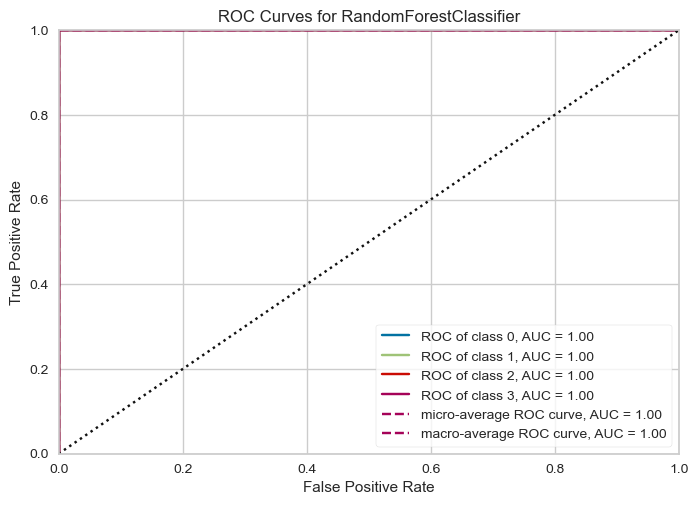

In [26]:
classification.plot_model(tuned_rf, plot = 'auc')

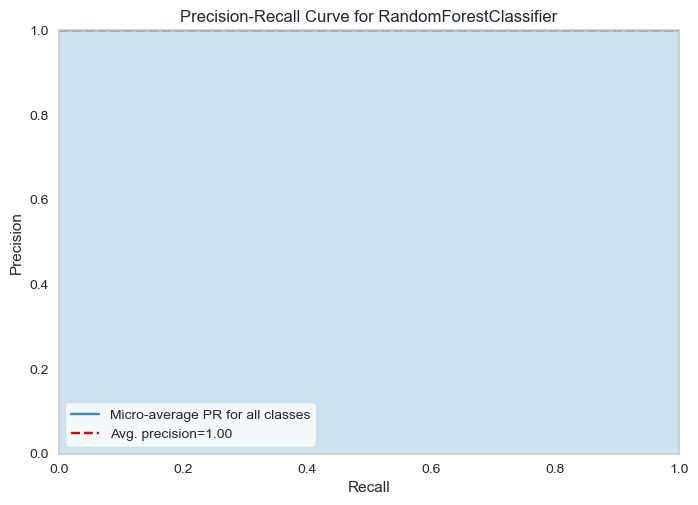

In [27]:
classification.plot_model(tuned_rf, plot = 'pr')

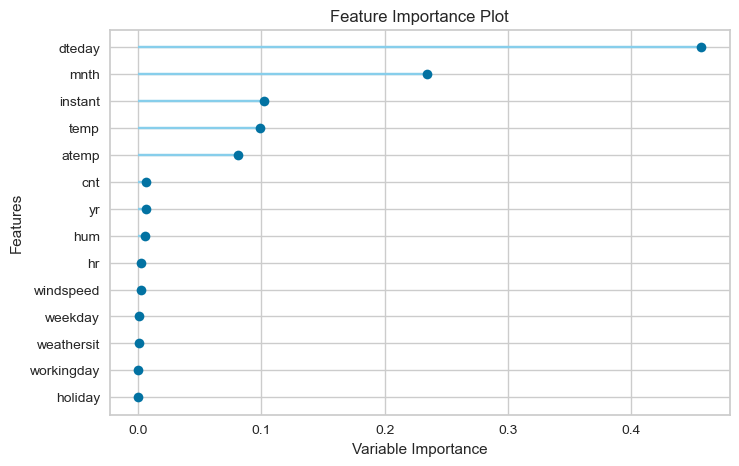

In [28]:
classification.plot_model(tuned_rf, plot='feature_all')

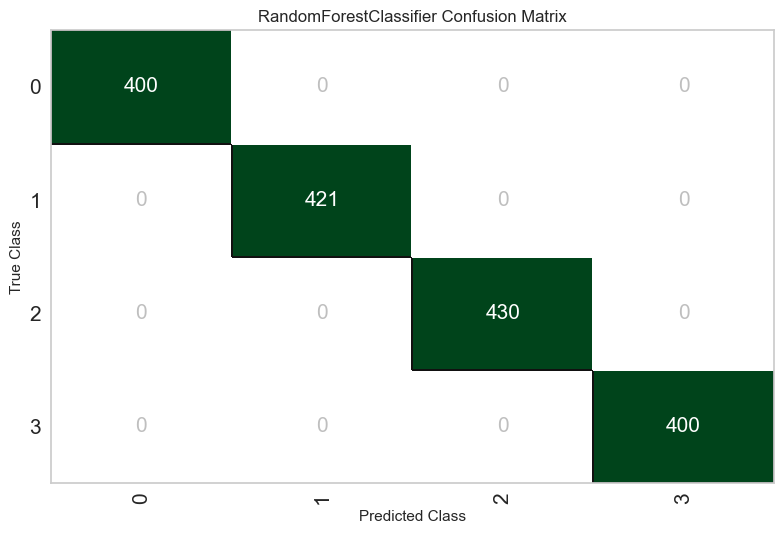

In [29]:
classification.plot_model(tuned_rf, plot = 'confusion_matrix')

In [30]:
classification.predict_model(tuned_rf);

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [31]:
# finalize rf model
final_rf = classification.finalize_model(tuned_rf)
# print final model parameters
print(final_rf)

Pipeline(memory=FastMemory(location=C:\Users\Nikita\AppData\Local\Temp\joblib),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['instant', 'yr', 'mnth', 'hr',
                                             'holiday', 'weekday', 'workingday',
                                             'weathersit', 'temp', 'atemp',
                                             'hum', 'wind...
                 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                        class_weight=None, criterion='gini',
                                        max_depth=None, max_features='auto',
                                        max_leaf_nodes=None, max_samples=None,
                                        min_imp

In [32]:
classification.predict_model(final_rf);

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [33]:
unseen_predictions = classification.predict_model(final_rf, data=data_unseen)
unseen_predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,season,prediction_label,prediction_score
0,6,1/1/2011,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,1,1,1,1.0
1,40,1/2/2011,0,1,16,0,0,0,3,0.34,0.3333,0.71,0.1642,76,1,1,1.0
2,58,1/3/2011,0,1,12,0,1,1,1,0.22,0.2121,0.35,0.2985,61,1,1,1.0
3,73,1/4/2011,0,1,4,0,2,1,1,0.14,0.1818,0.63,0.0896,2,1,1,1.0
4,104,1/5/2011,0,1,12,0,3,1,1,0.26,0.2273,0.33,0.3284,79,1,1,1.0


In [34]:
unseen_predictions[unseen_predictions['windspeed'] > 0.03]

,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,season,prediction_label,prediction_score
0,6,1/1/2011,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,1,1,1,1.00
1,40,1/2/2011,0,1,16,0,0,0,3,0.34,0.3333,0.71,0.1642,76,1,1,1.00
2,58,1/3/2011,0,1,12,0,1,1,1,0.22,0.2121,0.35,0.2985,61,1,1,1.00
3,73,1/4/2011,0,1,4,0,2,1,1,0.14,0.1818,0.63,0.0896,2,1,1,1.00
4,104,1/5/2011,0,1,12,0,3,1,1,0.26,0.2273,0.33,0.3284,79,1,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864,17362,12/31/2012,1,12,6,0,1,1,1,0.16,0.1667,0.64,0.1642,40,1,1,1.00
865,17363,12/31/2012,1,12,7,0,1,1,1,0.16,0.1818,0.64,0.1343,85,1,1,1.00
866,17364,12/31/2012,1,12,8,0,1,1,1,0.14,0.1515,0.69,0.1343,196,1,1,0.99
867,17366,12/31/2012,1,12,10,0,1,1,2,0.20,0.2121,0.69,0.1343,120,1,1,1.00


In [37]:
classification.save_model(final_rf,'result')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=FastMemory(location=C:\Users\Nikita\AppData\Local\Temp\joblib),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['instant', 'yr', 'mnth', 'hr',
                                              'holiday', 'weekday', 'workingday',
                                              'weathersit', 'temp', 'atemp',
                                              'hum', 'wind...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',
                                         max_depth=None, max_features='auto',
                                         max_leaf_nodes=None, max_samples=None,
                                 

In [38]:
saved_final_rf = classification.load_model('result')

Transformation Pipeline and Model Successfully Loaded


In [39]:
new_prediction = classification.predict_model(saved_final_rf, data=data_unseen)
new_prediction.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,season,prediction_label,prediction_score
0,6,1/1/2011,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,1,1,1,1.0
1,40,1/2/2011,0,1,16,0,0,0,3,0.34,0.3333,0.71,0.1642,76,1,1,1.0
2,58,1/3/2011,0,1,12,0,1,1,1,0.22,0.2121,0.35,0.2985,61,1,1,1.0
3,73,1/4/2011,0,1,4,0,2,1,1,0.14,0.1818,0.63,0.0896,2,1,1,1.0
4,104,1/5/2011,0,1,12,0,3,1,1,0.26,0.2273,0.33,0.3284,79,1,1,1.0
